In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from scipy import stats
from scipy.stats.mstats import winsorize

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer


## Loading Dataset : ( Cars Dataset )

In [2]:
original_data = pd.read_csv('used_cars_dataset.csv')

df = original_data.copy()

df.head()

,brand,year,fuel_type,transmission,mileage_kmpl,engine_cc,horsepower,owners,insurance_valid,city,price_lakh
0,Mahindra,2015,Electric,Automatic,21.99,1971,187.0,1,Yes,Elizabethborough,5.55
1,BMW,2020,CNG,Automatic,16.65,2048,211.0,3,Yes,Dianestad,3.96
2,Hyundai,2007,Electric,Manual,15.87,1928,69.0,3,Yes,Hicksville,18.78
3,Mahindra,2010,Diesel,Manual,16.28,3203,97.0,2,No,Riveraside,10.54
4,Ford,2018,Electric,Manual,14.11,2361,164.0,2,Yes,Weaverfort,5.62


## Basic Info :

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   brand            6000 non-null   object 
 1   year             6000 non-null   int64  
 2   fuel_type        6000 non-null   object 
 3   transmission     6000 non-null   object 
 4   mileage_kmpl     5700 non-null   float64
 5   engine_cc        6000 non-null   int64  
 6   horsepower       5700 non-null   float64
 7   owners           6000 non-null   int64  
 8   insurance_valid  5700 non-null   object 
 9   city             6000 non-null   object 
 10  price_lakh       6000 non-null   float64
dtypes: float64(3), int64(3), object(5)
memory usage: 515.8+ KB


,year,mileage_kmpl,engine_cc,horsepower,owners,price_lakh
count,6000.000000,5700.000000,6000.000000,5700.000000,6000.000000,6000.000000
mean,2014.155333,17.987784,2145.985667,188.831228,2.512167,7.928865
std,5.483449,3.922833,783.669174,75.953463,1.113130,4.084053
min,2005.000000,4.040000,800.000000,60.000000,1.000000,-9.860000
25%,2009.000000,15.310000,1463.750000,123.000000,2.000000,5.110000
50%,2014.000000,17.950000,2138.000000,189.000000,2.000000,7.900000
75%,2019.000000,20.612500,2828.250000,256.000000,4.000000,10.720000
max,2023.000000,31.270000,3499.000000,319.000000,4.000000,22.910000


## Missing Value Identification and Percentage :

In [4]:
missing_count = df.isnull().sum()
missing_percent = (missing_count/len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing (%)': missing_percent,
})

missing_df

,Missing Count,Missing (%)
brand,0,0.0
year,0,0.0
fuel_type,0,0.0
transmission,0,0.0
mileage_kmpl,300,5.0
engine_cc,0,0.0
horsepower,300,5.0
owners,0,0.0
insurance_valid,300,5.0
city,0,0.0


## Checking Distribution : (Missing Numerical Feature Only)

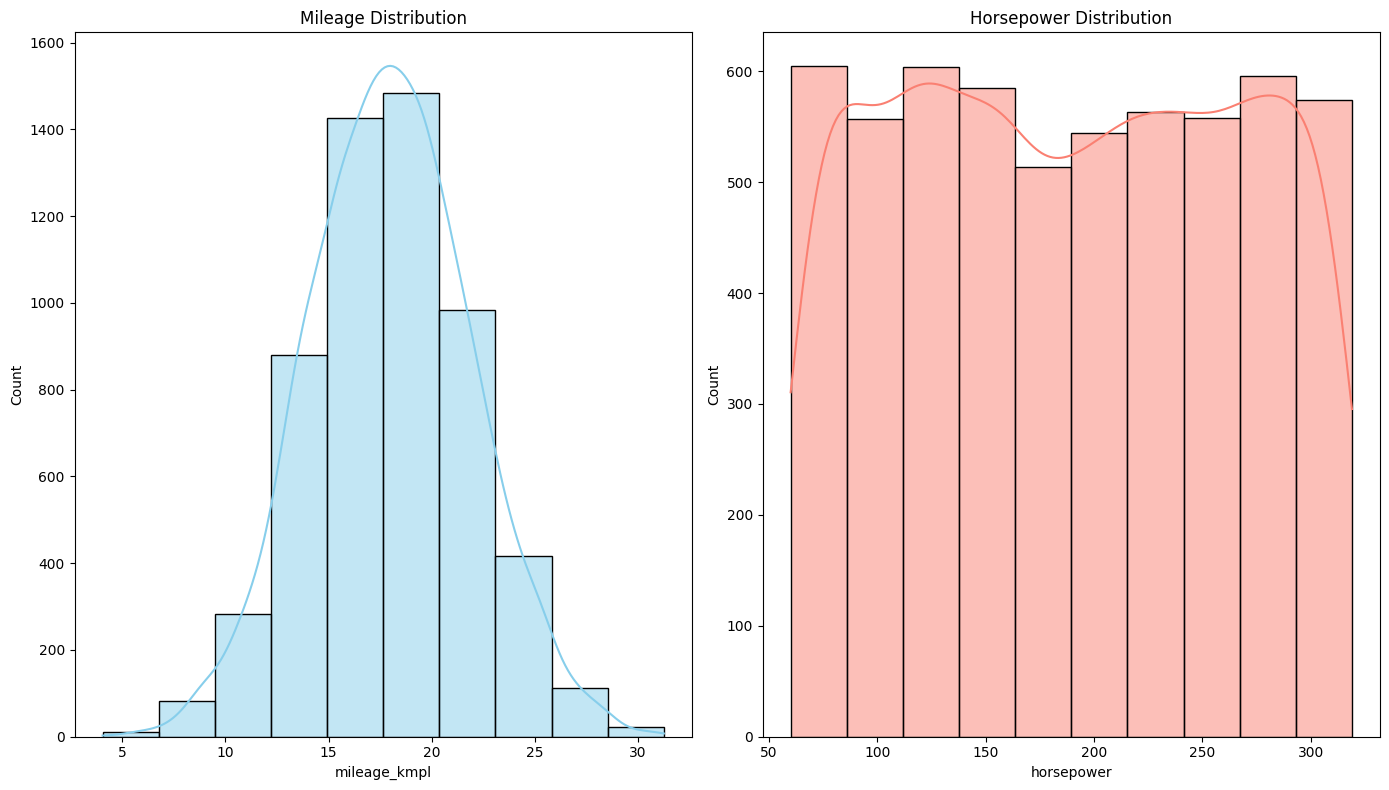

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.histplot(df['mileage_kmpl'], bins=10, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Mileage Distribution')

sns.histplot(df['horsepower'], bins=10, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Horsepower Distribution')

plt.tight_layout()
plt.show()

## Missing Value Imputation :

In [6]:
mean_imputer = SimpleImputer(strategy='mean')

df['mileage_kmpl'] = mean_imputer.fit_transform(df[['mileage_kmpl']])
df['horsepower'] = mean_imputer.fit_transform(df[['horsepower']])

In [7]:
df['insurance_missing'] = ( df['insurance_valid'].isnull().astype(int))

In [8]:
mode_imputer = SimpleImputer(strategy='most_frequent')

df['insurance_valid'] = (mode_imputer.fit_transform(df[['insurance_valid']]).ravel())

In [9]:
df.isnull().sum()

brand                0
year                 0
fuel_type            0
transmission         0
mileage_kmpl         0
engine_cc            0
horsepower           0
owners               0
insurance_valid      0
city                 0
price_lakh           0
insurance_missing    0
dtype: int64

In [10]:
df.head()

,brand,year,fuel_type,transmission,mileage_kmpl,engine_cc,horsepower,owners,insurance_valid,city,price_lakh,insurance_missing
0,Mahindra,2015,Electric,Automatic,21.99,1971,187.0,1,Yes,Elizabethborough,5.55,0
1,BMW,2020,CNG,Automatic,16.65,2048,211.0,3,Yes,Dianestad,3.96,0
2,Hyundai,2007,Electric,Manual,15.87,1928,69.0,3,Yes,Hicksville,18.78,0
3,Mahindra,2010,Diesel,Manual,16.28,3203,97.0,2,No,Riveraside,10.54,0
4,Ford,2018,Electric,Manual,14.11,2361,164.0,2,Yes,Weaverfort,5.62,0


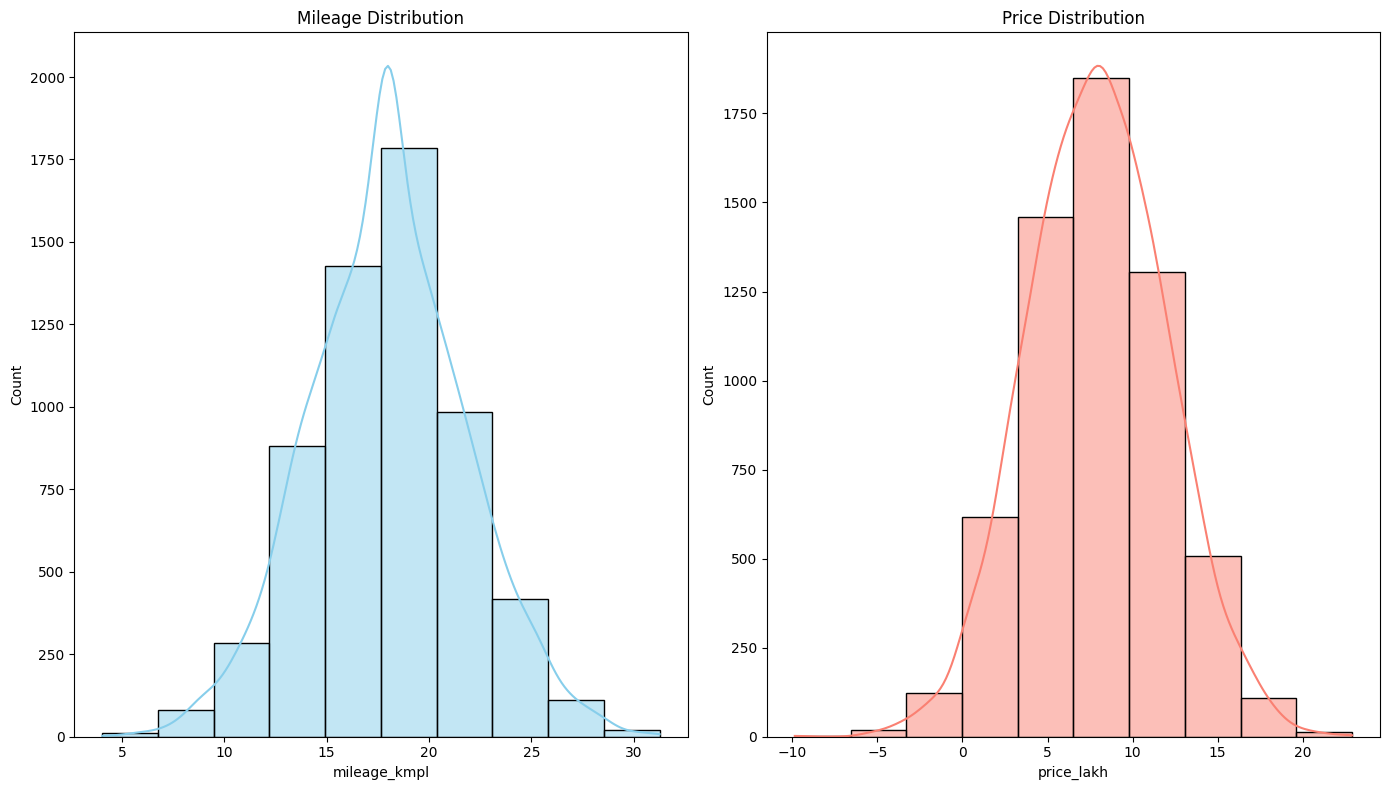

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.histplot(df['mileage_kmpl'], bins=10, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Mileage Distribution')

sns.histplot(df['price_lakh'], bins=10, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Price Distribution')

plt.tight_layout()
plt.show()

In [12]:
df.loc[df['price_lakh'] < 0, 'price_lakh'] = np.nan

In [13]:
mean_imputer = SimpleImputer(strategy='mean')

df['price_lakh'] = mean_imputer.fit_transform(df[['price_lakh']])

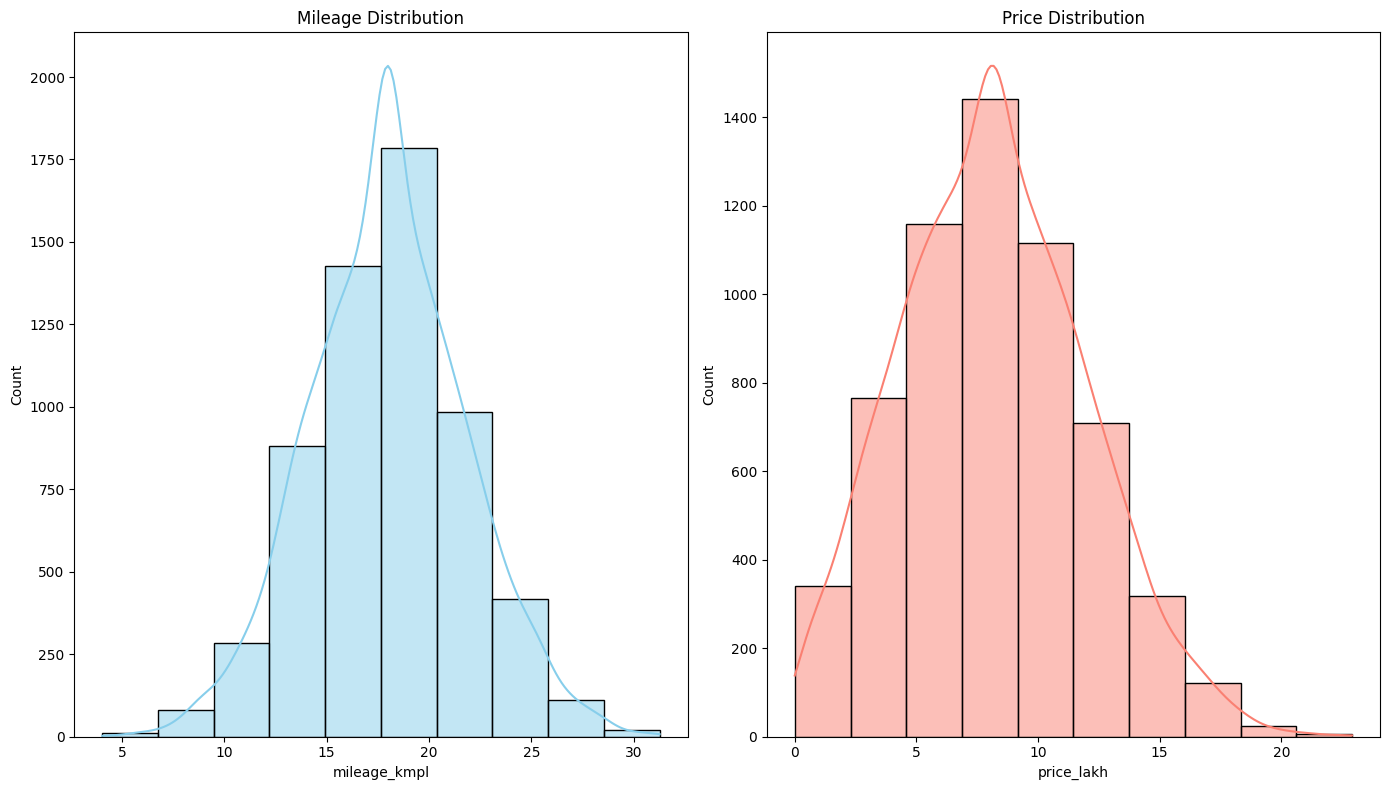

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.histplot(df['mileage_kmpl'], bins=10, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Mileage Distribution')

sns.histplot(df['price_lakh'], bins=10, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Price Distribution')

plt.tight_layout()
plt.show()

## Identifying Outlier :

<Axes: ylabel='price_lakh'>

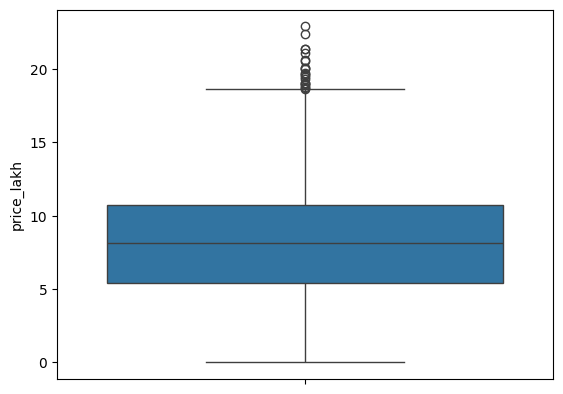

In [15]:
import seaborn as sns

sns.boxplot(df['price_lakh'])

In [16]:
df

,brand,year,fuel_type,transmission,mileage_kmpl,engine_cc,horsepower,owners,insurance_valid,city,price_lakh,insurance_missing
0,Mahindra,2015,Electric,Automatic,21.99,1971,187.000000,1,Yes,Elizabethborough,5.55,0
1,BMW,2020,CNG,Automatic,16.65,2048,211.000000,3,Yes,Dianestad,3.96,0
2,Hyundai,2007,Electric,Manual,15.87,1928,69.000000,3,Yes,Hicksville,18.78,0
3,Mahindra,2010,Diesel,Manual,16.28,3203,97.000000,2,No,Riveraside,10.54,0
4,Ford,2018,Electric,Manual,14.11,2361,164.000000,2,Yes,Weaverfort,5.62,0
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,BMW,2010,Electric,Manual,24.00,2165,217.000000,3,No,Gabriellehaven,3.53,0
5996,Ford,2021,Electric,Manual,15.23,1518,287.000000,3,Yes,Lake Diana,12.21,0
5997,Ford,2021,Electric,Manual,24.77,1349,293.000000,4,Yes,West Johnport,2.52,0
5998,Hyundai,2023,Electric,Manual,19.46,2171,188.831228,4,No,Port Michaelfort,5.33,0


## Dropping Unnecessary Features :

In [17]:
df['city'].value_counts()

city
West Michael           8
East Jennifer          7
South Michael          7
Johnborough            7
New Jennifer           7
                      ..
Brightburgh            1
East Anthonychester    1
Collinston             1
South Adrianborough    1
West Johnport          1
Name: count, Length: 5038, dtype: int64

In [18]:
df['horsepower'] = df['horsepower'].round(0)

In [19]:
df.drop(columns=['city'], inplace=True)

In [20]:
df

,brand,year,fuel_type,transmission,mileage_kmpl,engine_cc,horsepower,owners,insurance_valid,price_lakh,insurance_missing
0,Mahindra,2015,Electric,Automatic,21.99,1971,187.0,1,Yes,5.55,0
1,BMW,2020,CNG,Automatic,16.65,2048,211.0,3,Yes,3.96,0
2,Hyundai,2007,Electric,Manual,15.87,1928,69.0,3,Yes,18.78,0
3,Mahindra,2010,Diesel,Manual,16.28,3203,97.0,2,No,10.54,0
4,Ford,2018,Electric,Manual,14.11,2361,164.0,2,Yes,5.62,0
...,...,...,...,...,...,...,...,...,...,...,...
5995,BMW,2010,Electric,Manual,24.00,2165,217.0,3,No,3.53,0
5996,Ford,2021,Electric,Manual,15.23,1518,287.0,3,Yes,12.21,0
5997,Ford,2021,Electric,Manual,24.77,1349,293.0,4,Yes,2.52,0
5998,Hyundai,2023,Electric,Manual,19.46,2171,189.0,4,No,5.33,0


## Feature Construction and Encoding :

In [21]:
df['car_age'] = 2026 - df['year']

df.drop(columns=['year'], inplace=True)

In [22]:
df

,brand,fuel_type,transmission,mileage_kmpl,engine_cc,horsepower,owners,insurance_valid,price_lakh,insurance_missing,car_age
0,Mahindra,Electric,Automatic,21.99,1971,187.0,1,Yes,5.55,0,11
1,BMW,CNG,Automatic,16.65,2048,211.0,3,Yes,3.96,0,6
2,Hyundai,Electric,Manual,15.87,1928,69.0,3,Yes,18.78,0,19
3,Mahindra,Diesel,Manual,16.28,3203,97.0,2,No,10.54,0,16
4,Ford,Electric,Manual,14.11,2361,164.0,2,Yes,5.62,0,8
...,...,...,...,...,...,...,...,...,...,...,...
5995,BMW,Electric,Manual,24.00,2165,217.0,3,No,3.53,0,16
5996,Ford,Electric,Manual,15.23,1518,287.0,3,Yes,12.21,0,5
5997,Ford,Electric,Manual,24.77,1349,293.0,4,Yes,2.52,0,5
5998,Hyundai,Electric,Manual,19.46,2171,189.0,4,No,5.33,0,3


In [23]:
luxury = ['BMW', 'Audi', 'Mercedes']

df['is_luxury'] = (
    df['brand']
    .isin(luxury)
    .astype(int)
)

In [24]:
onehot_cols = ['brand', 'fuel_type', 'transmission' , 'insurance_valid']

onehot_encoder = OneHotEncoder(drop='first',  sparse_output=False)

encoded_array = onehot_encoder.fit_transform(df[onehot_cols])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=onehot_encoder.get_feature_names_out(onehot_cols),
    index=df.index
)

df = df.drop(columns=onehot_cols)
df = pd.concat([df, encoded_df], axis=1)

In [25]:
df

,mileage_kmpl,engine_cc,horsepower,owners,price_lakh,insurance_missing,car_age,is_luxury,brand_Ford,brand_Honda,brand_Hyundai,brand_Kia,brand_Mahindra,brand_Toyota,fuel_type_Diesel,fuel_type_Electric,fuel_type_Petrol,transmission_Manual,insurance_valid_Yes
0,21.99,1971,187.0,1,5.55,0,11,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,16.65,2048,211.0,3,3.96,0,6,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,15.87,1928,69.0,3,18.78,0,19,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
3,16.28,3203,97.0,2,10.54,0,16,0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4,14.11,2361,164.0,2,5.62,0,8,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,24.00,2165,217.0,3,3.53,0,16,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
5996,15.23,1518,287.0,3,12.21,0,5,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
5997,24.77,1349,293.0,4,2.52,0,5,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
5998,19.46,2171,189.0,4,5.33,0,3,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [26]:
df['power_engine_ratio'] = (
    df['horsepower'] /
    df['engine_cc']
)

df['mileage_per_year'] = (
    df['mileage_kmpl'] /
    (df['car_age'] + 1)
)

In [27]:
df

,mileage_kmpl,engine_cc,horsepower,owners,price_lakh,insurance_missing,car_age,is_luxury,brand_Ford,brand_Honda,...,brand_Kia,brand_Mahindra,brand_Toyota,fuel_type_Diesel,fuel_type_Electric,fuel_type_Petrol,transmission_Manual,insurance_valid_Yes,power_engine_ratio,mileage_per_year
0,21.99,1971,187.0,1,5.55,0,11,0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.094876,1.832500
1,16.65,2048,211.0,3,3.96,0,6,1,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.103027,2.378571
2,15.87,1928,69.0,3,18.78,0,19,0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.035788,0.793500
3,16.28,3203,97.0,2,10.54,0,16,0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.030284,0.957647
4,14.11,2361,164.0,2,5.62,0,8,0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.069462,1.567778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,24.00,2165,217.0,3,3.53,0,16,1,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.100231,1.411765
5996,15.23,1518,287.0,3,12.21,0,5,0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.189065,2.538333
5997,24.77,1349,293.0,4,2.52,0,5,0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.217198,4.128333
5998,19.46,2171,189.0,4,5.33,0,3,0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.087057,4.865000


## Feature Scaling :

In [28]:
num_cols = ['mileage_kmpl','engine_cc','horsepower','owners','car_age','power_engine_ratio']

scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

In [29]:
df

,mileage_kmpl,engine_cc,horsepower,owners,price_lakh,insurance_missing,car_age,is_luxury,brand_Ford,brand_Honda,...,brand_Kia,brand_Mahindra,brand_Toyota,fuel_type_Diesel,fuel_type_Electric,fuel_type_Petrol,transmission_Manual,insurance_valid_Yes,power_engine_ratio,mileage_per_year
0,1.046832,-0.223309,-0.024852,-1.358595,5.55,0,-0.154052,0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.134907,1.832500
1,-0.349915,-0.125045,0.299368,0.438290,3.96,0,-1.065963,1,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.005715,2.378571
2,-0.553934,-0.278184,-1.618934,0.438290,18.78,0,1.305005,0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,-1.071356,0.793500
3,-0.446693,1.348914,-1.240678,-0.460152,10.54,0,0.757859,0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,-1.158591,0.957647
4,-1.014285,0.274392,-0.335563,-0.460152,5.62,0,-0.701199,0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,-0.537676,1.567778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1.572574,0.024265,0.380423,0.438290,3.53,0,0.757859,1,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.050034,1.411765
5996,-0.721335,-0.801407,1.326065,0.438290,12.21,0,-1.248345,0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.357852,2.538333
5997,1.773977,-1.017077,1.407120,1.336733,2.52,0,-1.248345,0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.803725,4.128333
5998,0.385077,0.031922,0.002166,1.336733,5.33,0,-1.613109,0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.258827,4.865000


In [31]:
Clean_dataset = df.copy()

Clean_dataset.head()

,mileage_kmpl,engine_cc,horsepower,owners,price_lakh,insurance_missing,car_age,is_luxury,brand_Ford,brand_Honda,...,brand_Kia,brand_Mahindra,brand_Toyota,fuel_type_Diesel,fuel_type_Electric,fuel_type_Petrol,transmission_Manual,insurance_valid_Yes,power_engine_ratio,mileage_per_year
0,1.046832,-0.223309,-0.024852,-1.358595,5.55,0,-0.154052,0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.134907,1.832500
1,-0.349915,-0.125045,0.299368,0.438290,3.96,0,-1.065963,1,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.005715,2.378571
2,-0.553934,-0.278184,-1.618934,0.438290,18.78,0,1.305005,0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,-1.071356,0.793500
3,-0.446693,1.348914,-1.240678,-0.460152,10.54,0,0.757859,0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,-1.158591,0.957647
4,-1.014285,0.274392,-0.335563,-0.460152,5.62,0,-0.701199,0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,-0.537676,1.567778
